# Turn-overshoot dataset — analysis

**Question on the table:** what does a full-speed in-place turn actually land on,
and can a linear equation `overshoot = c0 + c1 · turn_rate` predict it well enough
to aim short and land exactly on target?

**Dataset:** 58 pivots on the **playfield over the radio relay** (2026-07-11,
firmware `v0.20260711.13`), collected by `tests/bench/turn_sweep.py`:

| round | file | grid | purpose |
|---|---|---|---|
| 1 | `out/turn_sweep.csv` | 4 angles × 5 ceilings, sign alternating **across** cells | first look |
| 2 | `out/turn_sweep2.csv` | 4 angles × 4 ceilings, **both directions in every cell** | un-confound direction from angle |
| 3 | `out/turn_sweep_trace.csv` | ±90/±180/±360 at full ceiling, **full per-frame traces** | where inside the turn the error accrues |

Collection discipline (the hard-won bench rules): every turn starts from a
**verified-still** encoder baseline (both wheels < 5 mm/s for a 0.4 s dwell after a
ring-clearing STOP), sends are resent only after **proving** nothing started
(no busy flag AND no encoder movement for 3 s), and the final heading is
**encoder ground truth**: `θ = (Δenc_R − Δenc_L) / trackwidth`, trackwidth 128 mm.

Columns: `cmd_deg` (signed ask), `ceiling_wheel` (commanded per-wheel speed cap,
mm/s — 384 is the firmware default 6 rad/s), `peak_wheel` (measured peak |wheel
speed|), `final_deg` (landed heading), `overshoot_deg` (signed **toward the turn
direction**: + = turned too far).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

TRACKWIDTH = 128.0   # [mm]

rounds = {1: "out/turn_sweep.csv", 2: "out/turn_sweep2.csv", 3: "out/turn_sweep_trace.csv"}
df = pd.concat([pd.read_csv(f).assign(round=r) for r, f in rounds.items()], ignore_index=True)
df["mag"] = df.cmd_deg.abs()          # [deg] turn magnitude
df["sign"] = np.sign(df.cmd_deg).astype(int)
print(f"{len(df)} turns")
df

58 turns


,cmd_deg,ceiling_wheel,peak_wheel,final_deg,overshoot_deg,round,mag,sign
0,30.0,70.0,86.0,28.96,-1.04,1,30.0,1
1,-90.0,70.0,79.3,-88.75,-1.25,1,90.0,-1
2,180.0,70.0,85.4,178.64,-1.36,1,180.0,1
3,-360.0,70.0,81.2,-358.28,-1.72,1,360.0,-1
4,30.0,140.0,147.2,30.22,0.22,1,30.0,1
5,-90.0,140.0,169.7,-91.84,1.84,1,90.0,-1
6,180.0,140.0,168.7,182.50,2.50,1,180.0,1
7,-360.0,140.0,175.6,-362.42,2.42,1,360.0,-1
8,30.0,210.0,150.3,30.73,0.73,1,30.0,1
9,-90.0,210.0,247.0,-98.12,8.12,1,90.0,-1


## The grid, at a glance

Cell means (all rounds pooled). Rows = turn magnitude, columns = wheel-speed
ceiling. `n` = turns per cell, `sd` = run-to-run spread within the cell.

In [2]:
g = df.groupby(["mag", "ceiling_wheel"]).overshoot_deg
summary = pd.DataFrame({"mean": g.mean(), "sd": g.std(), "n": g.size()})
for k in ["mean", "sd"]:
    print(f"--- overshoot {k} [deg] ---")
    print(summary[k].unstack().round(2).to_string(), "\n")
print("--- n per cell ---")
print(summary["n"].unstack().to_string())

--- overshoot mean [deg] ---
ceiling_wheel  70.0   140.0  210.0  280.0  384.0
mag                                             
30.0           -1.04   0.58   0.89   0.69   0.65
90.0           -1.25   1.60   6.79   9.71   8.13
180.0          -1.36   2.30   2.58   5.24   5.45
360.0          -1.72   2.31   1.88   0.74   3.34 

--- overshoot sd [deg] ---
ceiling_wheel  70.0   140.0  210.0  280.0  384.0
mag                                             
30.0             NaN   0.66   0.76   0.88   0.77
90.0             NaN   0.80   1.25   1.14   2.95
180.0            NaN   0.45   0.60   1.08   1.29
360.0            NaN   0.92   0.37   0.46   0.73 

--- n per cell ---
ceiling_wheel  70.0   140.0  210.0  280.0  384.0
mag                                             
30.0               1      3      3      3      3
90.0               1      3      3      3      5
180.0              1      3      3      3      5
360.0              1      3      3      3      5


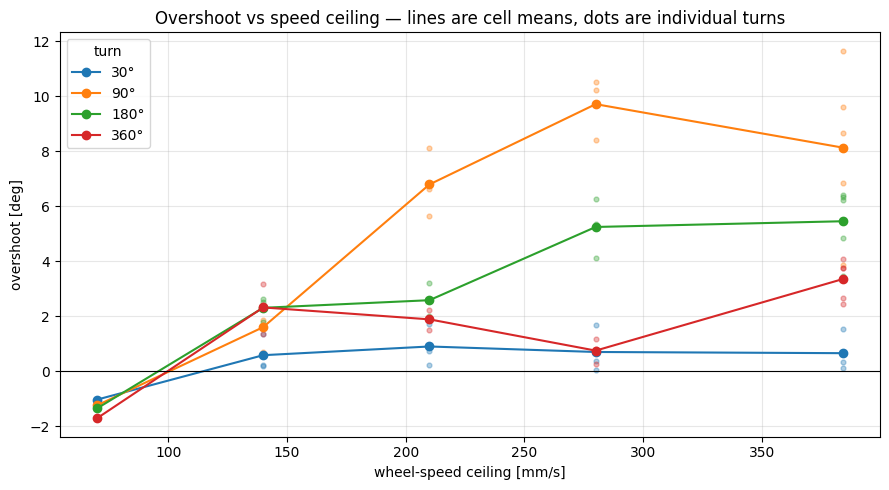

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for mag, sub in df.groupby("mag"):
    m = sub.groupby("ceiling_wheel").overshoot_deg.mean()
    ax.plot(m.index, m.values, "-o", label=f"{mag:.0f}°")
    ax.scatter(sub.ceiling_wheel, sub.overshoot_deg, s=12, alpha=0.35)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("wheel-speed ceiling [mm/s]"); ax.set_ylabel("overshoot [deg]")
ax.set_title("Overshoot vs speed ceiling — lines are cell means, dots are individual turns")
ax.legend(title="turn"); ax.grid(alpha=0.3)
plt.tight_layout()

**What the map says:**

- At **70 mm/s** everything **undershoots** a consistent −1.0…−1.7°.
- At **140 mm/s** everything is +0.2…+3.2 — mild.
- Above that the families **split**: 90° climbs to **+8…+10°**, 180° to ~+5.5°,
  while 360° stays around +1…+3 and 30° never leaves ±1.7 (its profile is
  acceleration-limited — it physically can't reach the higher ceilings, peak
  ≈ 150 mm/s no matter what you ask for).

So overshoot is **not a function of speed alone** — at the same commanded ceiling
the 90° turn overshoots 3–5× more than the 360°.

## The regressor a linear law would use

The natural predictor is the **rate the turn decelerates from** (the profile
peak): `ω_e = min(ceiling_rate, √(θ·α))` — capped by the ceiling on long turns,
acceleration-limited (triangular profile) on short ones. `α ≈ 10.5 rad/s²` is
implied by the 30° turns' measured plateau (~150 mm/s ⇒ 2.35 rad/s = √(0.524·α)).

overshoot ≈ -0.86 + 1.19·ω_e  [deg], ω in rad/s — R²=0.29


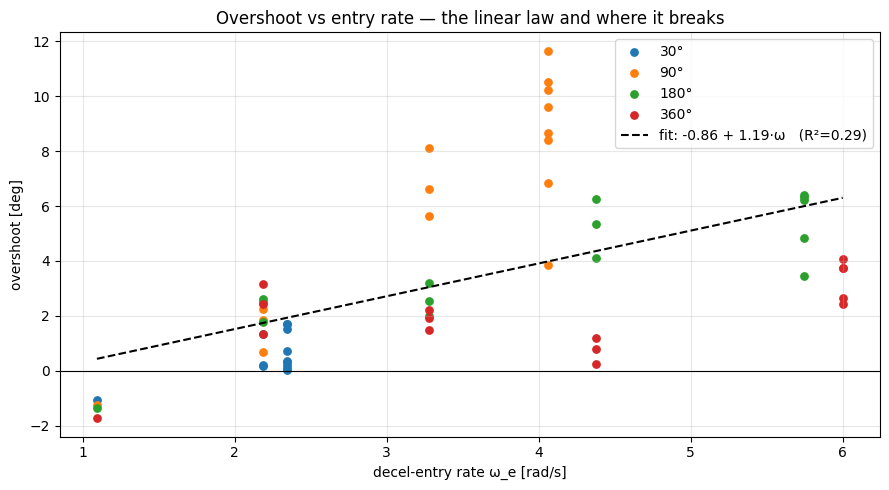

In [4]:
ALPHA = 10.5   # [rad/s^2] effective yaw accel implied by the 30° profile-limited peaks
df["omega_cap"] = df.ceiling_wheel / (TRACKWIDTH / 2)                     # [rad/s]
df["omega_e"] = np.minimum(df.omega_cap, np.sqrt(np.radians(df.mag) * ALPHA))

# global least-squares line, per the plan: overshoot = c0 + c1*omega_e
A = np.column_stack([np.ones(len(df)), df.omega_e])
(c0, c1), *_ = np.linalg.lstsq(A, df.overshoot_deg, rcond=None)
pred = A @ np.array([c0, c1])
r2 = 1 - np.sum((df.overshoot_deg - pred)**2) / np.sum((df.overshoot_deg - df.overshoot_deg.mean())**2)

fig, ax = plt.subplots(figsize=(9, 5))
for mag, sub in df.groupby("mag"):
    ax.scatter(sub.omega_e, sub.overshoot_deg, s=28, label=f"{mag:.0f}°")
xs = np.linspace(df.omega_e.min(), df.omega_e.max(), 50)
ax.plot(xs, c0 + c1 * xs, "k--", lw=1.5,
        label=f"fit: {c0:+.2f} + {c1:.2f}·ω   (R²={r2:.2f})")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("decel-entry rate ω_e [rad/s]"); ax.set_ylabel("overshoot [deg]")
ax.set_title("Overshoot vs entry rate — the linear law and where it breaks")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
print(f"overshoot ≈ {c0:+.2f} + {c1:.2f}·ω_e  [deg], ω in rad/s — R²={r2:.2f}")

**The linear law breaks on this map.** Look at ω_e ≈ 3.3 rad/s: the 90° turns
sit at +6…+8 while 180° and 360° at the *same entry rate* sit at +2…+3. At
ω_e ≈ 4.4, 180° reads +5 and 360° reads +1. And a perfect-triangle 180° at
full ceiling *decelerates from a higher rate* than the 90° yet overshoots half
as much. No function of entry rate alone — and none of the 2–3 parameter forms
I tried (`+θ`, `+ω/θ`, `+ω·e^(−θ/2)`, `ω²/θ`) — flattens the 90° ridge without
breaking the 30° or 360° families. The map is genuinely two-dimensional:
**angle × speed**, not speed.

## Direction and repeatability

Round 2 ran both directions in every cell specifically to check whether the
ridge was a CCW artifact (round 1's alternation had confounded them).

In [5]:
bydir = df[df["round"] == 2].pivot_table(index="mag", columns=["ceiling_wheel", "sign"],
                                          values="overshoot_deg")
print("--- round 2: overshoot by direction (+/-) ---")
print(bydir.round(1).to_string())
asym = (df.groupby("sign").overshoot_deg.mean())
print(f"\nmean overshoot, + turns: {asym[1]:+.2f}   − turns: {asym[-1]:+.2f}"
      f"   (direction asymmetry ≈ {asym[-1]-asym[1]:.1f}°)")

rep = df[df.groupby(["mag", "ceiling_wheel"]).overshoot_deg.transform("size") >= 3]
sd = rep.groupby(["mag", "ceiling_wheel"]).overshoot_deg.std()
print(f"\nrun-to-run sd within repeated cells: median {sd.median():.1f}°, worst "
      f"{sd.max():.1f}° ({sd.idxmax()})")

--- round 2: overshoot by direction (+/-) ---
ceiling_wheel 140.0      210.0      280.0       384.0     
sign             -1    1    -1    1    -1     1    -1    1
mag                                                       
30.0            1.3  0.2   1.7  0.2   1.7   0.0   1.5  0.3
90.0            2.2  0.7   6.6  5.6   8.4  10.2   8.7  9.6
180.0           2.6  1.8   2.6  3.2   6.3   4.1   6.3  4.8
360.0           3.2  1.3   2.2  1.9   1.2   0.3   2.7  3.8

mean overshoot, + turns: +2.66   − turns: +3.79   (direction asymmetry ≈ 1.1°)

run-to-run sd within repeated cells: median 0.8°, worst 3.0° ((np.float64(90.0), np.float64(384.0)))


Both directions show the same ridge (90° at 280: +10.2 CW / +8.4 CCW) —
**it's the angle, not the direction**. Direction contributes only ~1°
(negative turns run slightly hotter). But note the repeatability line: the same
commanded turn at speed varies **σ ≈ 2° run-to-run** (90@384 measured +11.65,
+9.6, +8.7, +6.9, +3.9 across rounds). That variance bounds what ANY fixed
compensation can deliver.

## Inside a turn: where does the surplus accrue?

Round 3 recorded every telemetry frame for six full-ceiling turns. From each
trace: heading from encoders, measured yaw rate from wheel velocities, and the
**commanded** yaw rate the executor was emitting (`cmd_vel` fields). If the
overshoot were wheel/robot inertia, we'd see the heading keep growing after the
command reaches zero (coast). 

In [6]:
import glob
def decompose(path):
    t_df = pd.read_csv(path)
    t = (t_df.now - t_df.now.iloc[0]).to_numpy() / 1000.0
    hdg = np.degrees(((t_df.enc_right - t_df.enc_right.iloc[0])
                      - (t_df.enc_left - t_df.enc_left.iloc[0])) / TRACKWIDTH)
    cmd = np.degrees((t_df.cmd_vel_right - t_df.cmd_vel_left).to_numpy() / TRACKWIDTH)
    meas = np.degrees((t_df.vel_right - t_df.vel_left).to_numpy() / TRACKWIDTH)
    sgn = np.sign(cmd[np.argmax(np.abs(cmd))])
    cmd_s, meas_s = cmd * sgn, meas * sgn
    surplus = meas_s - cmd_s                       # [deg/s] measured minus commanded
    pk = cmd_s.max(); hi = cmd_s >= 0.95 * pk
    i_a = np.argmax(hi); i_d = len(hi) - 1 - np.argmax(hi[::-1])
    seg = lambda lo, hi_: float(np.trapezoid(surplus[lo:hi_+1], t[lo:hi_+1])) if hi_ > lo else 0.0
    cmding = np.abs(cmd_s) > 3
    t_cmd0 = t[cmding].max()
    hdg_at_cmd0 = float(np.asarray(hdg)[t <= t_cmd0][-1])
    return dict(t=t, hdg=hdg, cmd=cmd_s, meas=meas_s, sgn=sgn, t_cmd0=t_cmd0,
                accel=seg(0, i_a), cruise=seg(i_a, i_d), decel=seg(i_d, len(t)-1),
                cmd_integral=float(np.trapezoid(cmd_s, t)),
                final=float(np.asarray(hdg)[-1] * 1), coast=float(np.asarray(hdg)[-1] - hdg_at_cmd0))

traces = {p.split("turn_trace_")[1].replace(".csv", ""): decompose(p)
          for p in sorted(glob.glob("out/turn_trace_*_384.csv"))}
rows = []
for name, d in traces.items():
    ask = float(name.split("_")[0])
    rows.append({"turn": name, "ask": ask, "landed": round(d["final"], 2),
                 "cmd_integral": round(d["cmd_integral"] * d["sgn"], 1),
                 "accel_deficit": round(d["accel"], 1), "cruise": round(d["cruise"], 1),
                 "decel_surplus": round(d["decel"], 1),
                 "coast_after_cmd0": round(d["sgn"] * d["coast"], 2)})
pd.DataFrame(rows).set_index("turn")

,ask,landed,cmd_integral,accel_deficit,cruise,decel_surplus,coast_after_cmd0
turn,,,,,,,
+180_384,180.0,186.23,183.0,-23.4,0.2,27.0,-1.35
+360_384,360.0,363.75,359.4,-23.4,-0.3,29.7,-1.41
+90_384,90.0,96.85,94.2,-21.5,0.7,23.4,-0.16
-180_384,-180.0,-186.41,-180.9,-22.3,-0.5,28.8,-0.90
-360_384,-360.0,-364.09,-358.3,-22.5,0.5,30.2,-1.15
-90_384,-90.0,-93.85,-90.0,-20.3,-0.3,24.4,-0.90


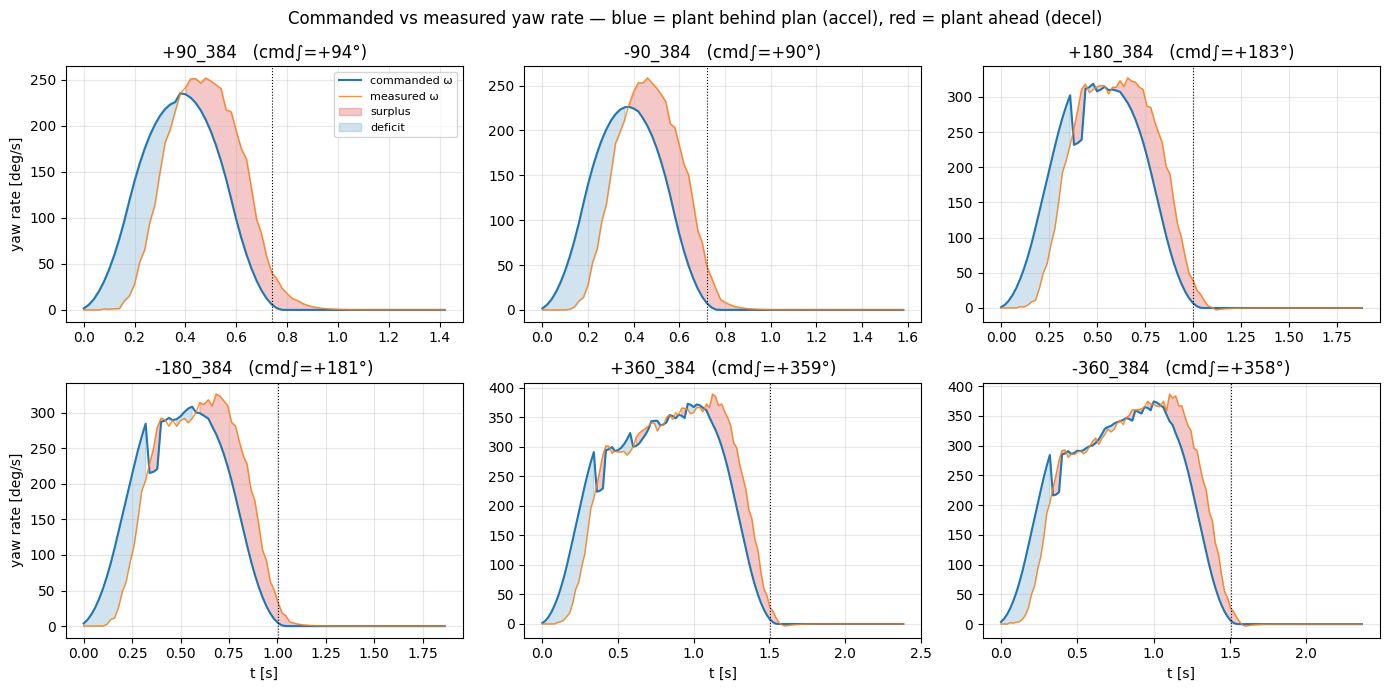

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=False)
order = ["+90_384", "-90_384", "+180_384", "-180_384", "+360_384", "-360_384"]
for ax, name in zip(axes.flat, order):
    d = traces[name]
    ax.plot(d["t"], d["cmd"], label="commanded ω", lw=1.5)
    ax.plot(d["t"], d["meas"], label="measured ω", lw=1.0, alpha=0.85)
    ax.fill_between(d["t"], d["cmd"], d["meas"], where=d["meas"] > d["cmd"],
                    color="tab:red", alpha=0.25, label="surplus")
    ax.fill_between(d["t"], d["cmd"], d["meas"], where=d["meas"] < d["cmd"],
                    color="tab:blue", alpha=0.20, label="deficit")
    ax.axvline(d["t_cmd0"], color="k", lw=0.8, ls=":")
    ax.set_title(f"{name}   (cmd∫={d['cmd_integral']:+.0f}°)")
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
for ax in axes[1]: ax.set_xlabel("t [s]")
for ax in axes[:, 0]: ax.set_ylabel("yaw rate [deg/s]")
fig.suptitle("Commanded vs measured yaw rate — blue = plant behind plan (accel), red = plant ahead (decel)")
plt.tight_layout()

**The verdict from the traces — it is NOT coast.**

- **Coast after command-zero is ±1°** (last column above). The wheels stop when
  told to. There is no inertia tail to pre-aim for.
- The turn's error budget is two big, nearly-cancelling transients: the plant
  runs **behind** the command during accel (blue, ≈ −22°) and **ahead** of it
  during decel (red, ≈ +24…+30°). The landing error is the *difference* of
  those two ~25° numbers — which is also why repeated runs scatter by ±2–3°:
  a 10% wobble in either transient moves the endpoint degrees.
- The `cmd∫` column shows a second contributor: on some turns the **commanded
  integral itself exceeds the ask** (e.g. +94° commanded on a +90° ask). That is
  the executor's mid-turn **divergence replan** re-adding the accel deficit:
  it re-anchors to the measured (lagging) position and re-commands the
  remaining angle — forgiving the deficit that would otherwise cancel the decel
  surplus. Short fast turns (90°) spend their whole life in the transient where
  this fires hardest → the ridge.
- The terminal stop *is* encoder-based (`STOP_ROTATION` fires on measured arc,
  `segment_executor.cpp` stop-eval), but after firing the executor **rides the
  plan's remaining tail open-loop** — so whatever the plant is ahead by at fire
  time is delivered *again* on top of the target.

## What a linear compensation would actually deliver

Fitting `overshoot = c0 + c1·ω_e` on the **cell means** (equal weight per cell)
and predicting the post-compensation landing per cell (`mean − prediction`):

In [8]:
cells = df.groupby(["mag", "ceiling_wheel"]).agg(
    over=("overshoot_deg", "mean"), we=("omega_e", "first")).reset_index()
A = np.column_stack([np.ones(len(cells)), cells.we])
(k0, k1), *_ = np.linalg.lstsq(A, cells.over, rcond=None)
cells["landing"] = cells.over - (k0 + k1 * cells.we)
print(f"cell-mean fit: overshoot ≈ {k0:+.2f} + {k1:.2f}·ω_e  [deg]"
      f"   (c1 = {np.radians(k1)*1000:.0f} ms of effective lag)")
print("\n--- predicted landing error AFTER aim-short compensation [deg] ---")
print(cells.pivot(index="mag", columns="ceiling_wheel", values="landing").round(1).to_string())

cell-mean fit: overshoot ≈ -2.03 + 1.50·ω_e  [deg]   (c1 = 26 ms of effective lag)

--- predicted landing error AFTER aim-short compensation [deg] ---
ceiling_wheel  70.0   140.0  210.0  280.0  384.0
mag                                             
30.0            -0.7   -0.7   -0.6   -0.8   -0.8
90.0            -0.9    0.3    3.9    5.6    4.1
180.0           -1.0    1.0   -0.3    0.7   -1.2
360.0           -1.3    1.1   -1.0   -3.8   -3.6


## Where this leaves us — for discussion

1. **The guessed model (`c0 + c1·rate`) is falsified by the data.** Best
   two-parameter line: `−2.0 + 1.5·ω_e`. It centers the slow and long turns to
   ±1.3° but leaves the **fast 90° ridge at +4…+6** and overcorrects fast 360°
   to −3.8. The map is angle × speed; no 2–3 parameter smooth law flattens it.
2. **The mechanism is in the executor/loop interplay, not the plant:** decel
   surplus vs accel deficit asymmetry, replan deficit-forgiveness, and
   ride-the-tail delivering the plant-ahead surplus past the measured stop.
   All three are *firmware-addressable* — e.g. truncating the ridden tail at
   the measured remaining budget closes the terminal on position and should
   kill both the bias **and** most of the run-to-run variance at the source.
3. **Run-to-run σ ≈ 2°** bounds any fixed table/equation: even a perfect
   per-cell lookup lands ±2° at full speed.

Options: **(A)** ship the linear compensation as config knobs and accept the
ridge; **(B)** fix the terminal/replan accounting first, then re-measure — the
residual after that should be the small, genuinely speed-proportional part a
2-parameter law CAN carry; **(C)** both in one flash.